### Project Title: Can a CNN Distinguish Between Real Photographs and AI-Generated Images?

### Course: Computational Intelligence 2

### Student: Fatemeh Aghaei




In [68]:
import os
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from tqdm.auto import tqdm

In [69]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"Using device: {device}")

PyTorch version: 2.13.0+cpu
Using device: cpu


In [148]:
# Main configuration

IMAGE_SIZE = 224
DATA_DIR = Path("data")

print("Image size:", IMAGE_SIZE)
print("Dataset path:", DATA_DIR)

Image size: 224
Dataset path: data


##### Hyperparameter Settings

| Parameter | Custom CNN | ResNet50 | EfficientNet-B0 |
|---|---:|---:|---:|
| Image Size | 224 × 224 | 224 × 224 | 224 × 224 |
| Batch Size | 64 | 64 | 64 |
| Epochs | 15 | 15 | 15 |
| Optimizer | Adam | Adam | Adam |
| Learning Rate | 0.0001 | 0.001 | 0.001 |
| Loss Function | CrossEntropyLoss | CrossEntropyLoss | CrossEntropyLoss |

##### Hyperparameter Selection

The custom CNN was trained with a learning rate of **0.0001**, while ResNet50 and EfficientNet-B0 used a learning rate of **0.001**. Since the pretrained models only updated their final classification layer, a higher learning rate was appropriate, whereas the custom CNN was trained from scratch using a smaller learning rate.

## Dataset

This project uses the **AI vs. Human-Generated Images** dataset from Kaggle.

Dataset:
https://www.kaggle.com/datasets/alessandrasala79/ai-vs-human-generated-dataset

In [71]:
from pathlib import Path

DATA_DIR = Path("data")
TRAIN_CSV = DATA_DIR / "train.csv"
TEST_CSV = DATA_DIR / "test.csv"

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Training data shape:", train_df.shape)
print("Test data shape:", test_df.shape)

Training data shape: (79950, 3)
Test data shape: (5540, 1)


In [72]:
display(train_df.head())
display(test_df.head())

,Unnamed: 0,file_name,label
0,0,train_data/a6dcb93f596a43249135678dfcfc17ea.jpg,1
1,1,train_data/041be3153810433ab146bc97d5af505c.jpg,0
2,2,train_data/615df26ce9494e5db2f70e57ce7a3a4f.jpg,1
3,3,train_data/8542fe161d9147be8e835e50c0de39cd.jpg,0
4,4,train_data/5d81fa12bc3b4cea8c94a6700a477cf2.jpg,1


,id
0,test_data_v2/1a2d9fd3e21b4266aea1f66b30aed157.jpg
1,test_data_v2/ab5df8f441fe4fbf9dc9c6baae699dc7.jpg
2,test_data_v2/eb364dd2dfe34feda0e52466b7ce7956.jpg
3,test_data_v2/f76c2580e9644d85a741a42c6f6b39c0.jpg
4,test_data_v2/a16495c578b7494683805484ca27cf9f.jpg


In [73]:
print("Train columns:", train_df.columns.tolist())
print("Test columns:", test_df.columns.tolist())

Train columns: ['Unnamed: 0', 'file_name', 'label']
Test columns: ['id']


##### Checking data types and empty values

In [74]:
print("Training dataframe information:")
train_df.info()

print("\nMissing values in training data:")
print(train_df.isnull().sum())

print("\nMissing values in test data:")
print(test_df.isnull().sum())

Training dataframe information:


<class 'pandas.DataFrame'>
RangeIndex: 79950 entries, 0 to 79949
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  79950 non-null  int64
 1   file_name   79950 non-null  str  
 2   label       79950 non-null  int64
dtypes: int64(2), str(1)
memory usage: 1.8 MB

Missing values in training data:
Unnamed: 0    0
file_name     0
label         0
dtype: int64

Missing values in test data:
id    0
dtype: int64


##### Checking the distribution of labels:

In [75]:
for column in train_df.columns:
    unique_count = train_df[column].nunique()

    if unique_count <= 10:
        print(f"\nColumn: {column}")
        print(train_df[column].value_counts(dropna=False))


Column: label
label
1    39975
0    39975
Name: count, dtype: int64


##### Check for image folders

In [76]:
TRAIN_IMAGE_DIR = DATA_DIR / "train_data"
TEST_IMAGE_DIR = DATA_DIR / "test_data_v2"

print("Train image directory exists:", TRAIN_IMAGE_DIR.exists())
print("Test image directory exists:", TEST_IMAGE_DIR.exists())

Train image directory exists: True
Test image directory exists: True


In [77]:
image_extensions = {".jpg", ".jpeg", ".png", ".webp"}

train_image_count = sum(
    1
    for path in TRAIN_IMAGE_DIR.iterdir()
    if path.is_file() and path.suffix.lower() in image_extensions
)

test_image_count = sum(
    1
    for path in TEST_IMAGE_DIR.iterdir()
    if path.is_file() and path.suffix.lower() in image_extensions
)

print("Number of training images:", train_image_count)
print("Number of test images:", test_image_count)

Number of training images: 79950
Number of test images: 5540


In [78]:
train_df.columns

Index(['Unnamed: 0', 'file_name', 'label'], dtype='str')

In [79]:
train_df = train_df.drop(columns=["Unnamed: 0"], errors="ignore")
test_df = test_df.drop(columns=["Unnamed: 0"], errors="ignore")

print("Train columns:", train_df.columns.tolist())
print("Test columns:", test_df.columns.tolist())

Train columns: ['file_name', 'label']
Test columns: ['id']


In [80]:
label_percentages = train_df["label"].value_counts(normalize=True).sort_index() * 100

print("Class percentages:")
print(label_percentages)

Class percentages:
label
0    50.0
1    50.0
Name: proportion, dtype: float64


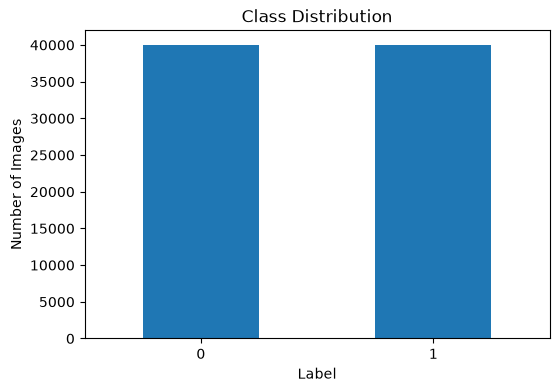

In [81]:
plt.figure(figsize=(6, 4))
label_counts.plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.show()

In [82]:
from pathlib import Path

DATA_DIR = Path("data")

train_df["image_path"] = train_df["file_name"].apply(
    lambda file_name: DATA_DIR / file_name
)

train_df.head()

,file_name,label,image_path
0,train_data/a6dcb93f596a43249135678dfcfc17ea.jpg,1,data\train_data\a6dcb93f596a43249135678dfcfc17...
1,train_data/041be3153810433ab146bc97d5af505c.jpg,0,data\train_data\041be3153810433ab146bc97d5af50...
2,train_data/615df26ce9494e5db2f70e57ce7a3a4f.jpg,1,data\train_data\615df26ce9494e5db2f70e57ce7a3a...
3,train_data/8542fe161d9147be8e835e50c0de39cd.jpg,0,data\train_data\8542fe161d9147be8e835e50c0de39...
4,train_data/5d81fa12bc3b4cea8c94a6700a477cf2.jpg,1,data\train_data\5d81fa12bc3b4cea8c94a6700a477c...


In [83]:
train_df["file_exists"] = train_df["image_path"].apply(lambda path: path.exists())

print("Existing images:", train_df["file_exists"].sum())
print("Missing images:", (~train_df["file_exists"]).sum())

Existing images: 79950
Missing images: 0


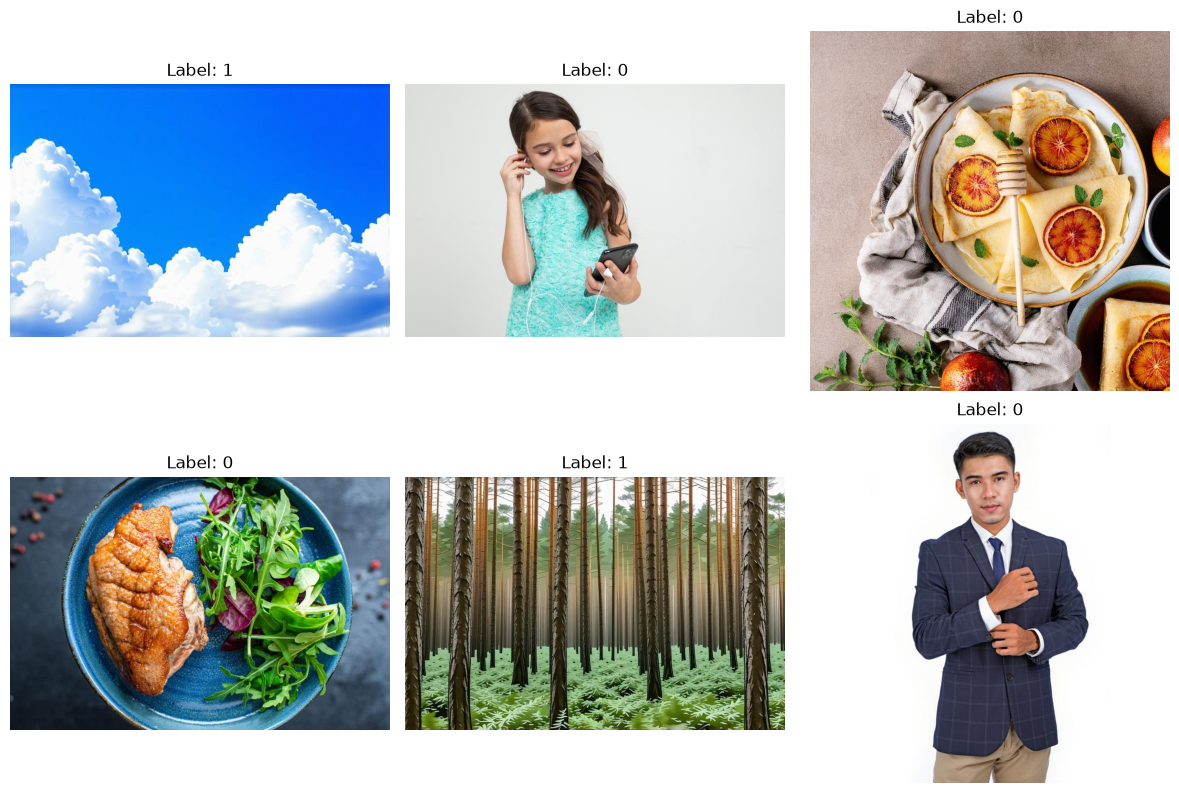

In [84]:
from PIL import Image
import matplotlib.pyplot as plt

sample_df = train_df.sample(6, random_state=42)

plt.figure(figsize=(12, 8))

for i, (_, row) in enumerate(sample_df.iterrows()):
    image = Image.open(row["image_path"]).convert("RGB")

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(f"Label: {row['label']}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [85]:
from sklearn.model_selection import train_test_split

train_split, val_split = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["label"]
)

print("Training samples:", len(train_split))
print("Validation samples:", len(val_split))

Training samples: 63960
Validation samples: 15990


#### Data Preprocessing and Augmentation

The dataset was divided into training and validation subsets using stratified sampling to preserve the class distribution.

Training images were augmented using random transformations to reduce overfitting and improve generalization. Validation images only received resizing and normalization so that the models were evaluated on unchanged data.

In [86]:
from torchvision import transforms

IMAGE_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

#### Creating a Custom PyTorch Dataset

##### Our images and labels are already stored in the dataset downloaded from Kaggle.

##### However, PyTorch cannot directly read information from the CSV file. Therefore, we create a custom `Dataset` class that tells PyTorch:

- where each image is located,
- what its corresponding label is,
- and which preprocessing or augmentation steps should be applied before training.

##### This class does **not create a new dataset**. It simply provides an organized way for PyTorch to load our existing images during training.

In [87]:
from torch.utils.data import Dataset
from PIL import Image

class ImageDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image = Image.open(row["image_path"]).convert("RGB")

        label = row["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

#### Creating Training and Validation Datasets

##### Using the custom Dataset class, we create two datasets:

- Training dataset
- Validation dataset

##### Different transformations are applied to each dataset. Training images use data augmentation, while validation images only use resizing and normalization.

In [101]:
train_dataset = ImageDataset(train_split, train_transform)

val_dataset = ImageDataset(val_split, val_transform)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))

Training images: 63960
Validation images: 15990


##### Creating DataLoaders

In [89]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

### Building a Custom CNN:

In [103]:
import torch
import torch.nn as nn

class CustomCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

##### Building the model and training settings

In [91]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CustomCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

print("Using device:", device)
print(model)

Using device: cpu
CustomCNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=2, bias=True)
  )
)


##### Training Setup



In [104]:
train_split_small = train_split.sample(
    n=min(10000, len(train_split)),
    random_state=42
).reset_index(drop=True)

val_split_small = val_split.sample(
    n=min(2000, len(val_split)),
    random_state=42
).reset_index(drop=True)

print("Training samples:", len(train_split_small))
print("Validation samples:", len(val_split_small))

Training samples: 10000
Validation samples: 2000


##### Dataset, DataLoader

In [105]:
from torch.utils.data import DataLoader

train_dataset_small = ImageDataset(
    train_split_small,
    transform=train_transform
)

val_dataset_small = ImageDataset(
    val_split_small,
    transform=val_transform
)

train_loader_small = DataLoader(
    train_dataset_small,
    batch_size=64,
    shuffle=True,
    num_workers=0
)

val_loader_small = DataLoader(
    val_dataset_small,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

##### Model test before training

In [106]:
images, labels = next(iter(train_loader_small))

images = images.to(device)

outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)

Input shape: torch.Size([64, 3, 224, 224])
Output shape: torch.Size([64, 2])


##### Training the Custom CNN

In [107]:
NUM_EPOCHS =15  

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []


for epoch in range(NUM_EPOCHS):

    # Training
    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader_small:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        train_total += labels.size(0)
        train_correct += (predictions == labels).sum().item()


    average_train_loss = train_loss / len(train_loader_small)
    train_accuracy = 100 * train_correct / train_total


    # Validation
    model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader_small:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            predictions = outputs.argmax(dim=1)

            val_total += labels.size(0)
            val_correct += (predictions == labels).sum().item()


    average_val_loss = val_loss / len(val_loader_small)
    val_accuracy = 100 * val_correct / val_total


    train_losses.append(average_train_loss)
    val_losses.append(average_val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
        f"Train Loss: {average_train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.2f}% | "
        f"Val Loss: {average_val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.2f}%"
    )

Epoch 1/15 | Train Loss: 0.4268 | Train Accuracy: 81.09% | Val Loss: 0.4128 | Val Accuracy: 80.50%
Epoch 2/15 | Train Loss: 0.3879 | Train Accuracy: 83.14% | Val Loss: 0.4907 | Val Accuracy: 74.40%
Epoch 3/15 | Train Loss: 0.3541 | Train Accuracy: 85.12% | Val Loss: 0.3720 | Val Accuracy: 82.80%
Epoch 4/15 | Train Loss: 0.3413 | Train Accuracy: 85.53% | Val Loss: 0.3234 | Val Accuracy: 87.85%
Epoch 5/15 | Train Loss: 0.3317 | Train Accuracy: 85.85% | Val Loss: 0.3298 | Val Accuracy: 86.05%
Epoch 6/15 | Train Loss: 0.3189 | Train Accuracy: 86.41% | Val Loss: 0.4275 | Val Accuracy: 78.35%
Epoch 7/15 | Train Loss: 0.3061 | Train Accuracy: 87.06% | Val Loss: 0.4784 | Val Accuracy: 75.00%
Epoch 8/15 | Train Loss: 0.2977 | Train Accuracy: 87.64% | Val Loss: 0.4127 | Val Accuracy: 79.70%
Epoch 9/15 | Train Loss: 0.2794 | Train Accuracy: 88.17% | Val Loss: 0.3203 | Val Accuracy: 86.35%
Epoch 10/15 | Train Loss: 0.2791 | Train Accuracy: 88.32% | Val Loss: 0.4317 | Val Accuracy: 78.40%
Epoch 11/

#### Custom CNN Training Analysis

The Custom CNN improved steadily during training. Training accuracy increased from **81%** to **90%**, while the training loss decreased from **0.43** to **0.24**.

The best validation accuracy reached **87.85%**, and the final validation accuracy was **85.80%**. Overall, the model achieved good performance with only mild signs of overfitting.

##### Loss Plot

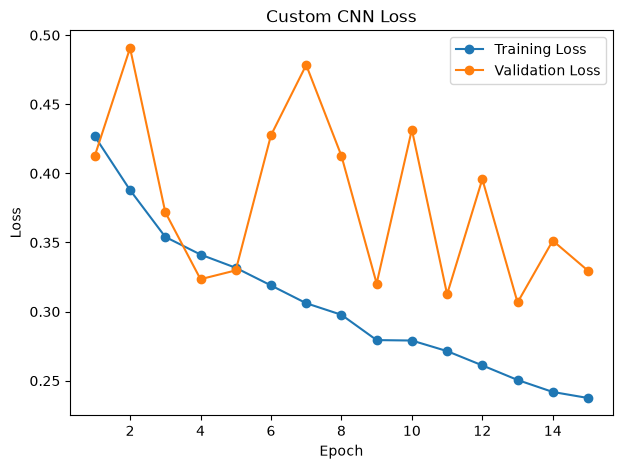

In [108]:
epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(7, 5))
plt.plot(epochs, train_losses, marker="o", label="Training Loss")
plt.plot(epochs, val_losses, marker="o", label="Validation Loss")
plt.title("Custom CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

##### Custom CNN Loss Analysis

The training loss consistently decreased during training, showing that the model learned effectively. Although the validation loss fluctuated between epochs, it remained relatively stable overall, suggesting good generalization with only mild signs of overfitting.

##### Accuracy

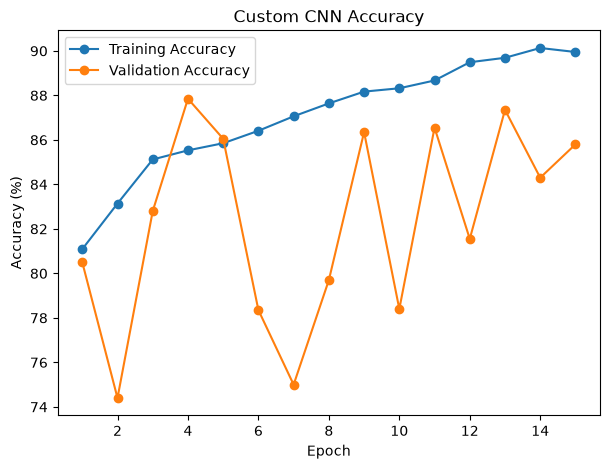

In [109]:
plt.figure(figsize=(7, 5))
plt.plot(epochs, train_accuracies, marker="o", label="Training Accuracy")
plt.plot(epochs, val_accuracies, marker="o", label="Validation Accuracy")
plt.title("Custom CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()

plt.show()

##### Custom CNN Accuracy Analysis

The training accuracy improved consistently throughout training, while the validation accuracy fluctuated across epochs. Despite these fluctuations, the model achieved a high validation accuracy of **87.85%**, indicating good overall performance with only mild signs of overfitting.

In [110]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model.eval()

true_labels = []
predicted_labels = []

with torch.no_grad():
    for images, labels in val_loader_small:
        images = images.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        true_labels.extend(labels.numpy())
        predicted_labels.extend(predictions.cpu().numpy())

accuracy = accuracy_score(true_labels, predicted_labels)
precision = precision_score(true_labels, predicted_labels)
recall = recall_score(true_labels, predicted_labels)
f1 = f1_score(true_labels, predicted_labels)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.858
Precision: 0.7973199329983249
Recall: 0.9577464788732394
F1 Score: 0.870201096892139


##### Confusion Matrix


<Figure size 600x600 with 0 Axes>

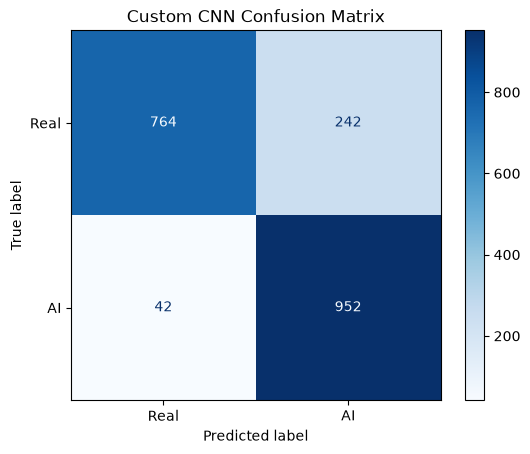

In [111]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, predicted_labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Real", "AI"]
)

plt.figure(figsize=(6,6))
disp.plot(cmap="Blues")
plt.title("Custom CNN Confusion Matrix")
plt.show()

##### Confusion Matrix Analysis

The model correctly classified most images, especially AI-generated images. It made relatively few false negatives but more false positives, indicating that it was more likely to classify real images as AI-generated than the opposite.

### ResNet50 (Transfer Learning)

##### Import the pretrained model

In [ ]:
from torchvision import models
import torch.nn as nn

##### Load pretrained ResNet50

In [113]:
resnet_model = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT
)

In [114]:
# Freeze all pretrained layers
# These weights will not be updated during training

for parameter in resnet_model.parameters():
    parameter.requires_grad = False

In [115]:
# Get the number of input features of the original final layer
number_of_features = resnet_model.fc.in_features

# Replace the original classifier with a new layer for two classes
resnet_model.fc = nn.Linear(
    number_of_features,
    2
)

In [ ]:
resnet_model = resnet_model.to(device)

# Display the new final layer
print(resnet_model.fc)

Linear(in_features=2048, out_features=2, bias=True)


##### Loss Function and Optimizer

In [117]:
resnet_criterion = nn.CrossEntropyLoss()

# Train only the new final layer
resnet_optimizer = torch.optim.Adam(
    resnet_model.fc.parameters(),
    lr=0.001
)

##### Test the model output

In [119]:
images, labels = next(iter(train_loader_small))
images = images.to(device)

# Pass the images through ResNet50
outputs = resnet_model(images)
print("ResNet50 output shape:", outputs.shape)

ResNet50 output shape: torch.Size([64, 2])


##### Train ResNet50

In [121]:
RESNET_EPOCHS = 15

# Lists for saving training results
resnet_train_losses = []
resnet_val_losses = []

resnet_train_accuracies = []
resnet_val_accuracies = []


for epoch in range(RESNET_EPOCHS):

   
    # Training phase
    resnet_model.train()

    training_loss = 0
    training_correct = 0
    training_total = 0

    for images, labels in train_loader_small:

        # Move data to CPU or GPU
        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        resnet_optimizer.zero_grad()

        # Make predictions
        outputs = resnet_model(images)

        # Calculate loss
        loss = resnet_criterion(outputs, labels)

        # Calculate gradients
        loss.backward()

        # Update the final layer
        resnet_optimizer.step()

        # Add batch loss
        training_loss += loss.item()

        # Convert model outputs to predicted class labels
        predictions = outputs.argmax(dim=1)

        # Count correct predictions
        training_total += labels.size(0)
        training_correct += (predictions == labels).sum().item()


    # Calculate average training loss and accuracy
    average_training_loss = training_loss / len(train_loader_small)
    training_accuracy = 100 * training_correct / training_total


    
    # Validation phase
    resnet_model.eval()

    validation_loss = 0
    validation_correct = 0
    validation_total = 0

    with torch.no_grad():

        for images, labels in val_loader_small:

            # Move data to CPU or GPU
            images = images.to(device)
            labels = labels.to(device)

            # Make predictions
            outputs = resnet_model(images)

            # Calculate validation loss
            loss = resnet_criterion(outputs, labels)

            # Add batch loss
            validation_loss += loss.item()

            # Convert outputs to predicted labels
            predictions = outputs.argmax(dim=1)

            # Count correct predictions
            validation_total += labels.size(0)
            validation_correct += (predictions == labels).sum().item()


    # Calculate average validation loss and accuracy
    average_validation_loss = validation_loss / len(val_loader_small)
    validation_accuracy = 100 * validation_correct / validation_total


    # Save results for plotting
    resnet_train_losses.append(average_training_loss)
    resnet_val_losses.append(average_validation_loss)

    resnet_train_accuracies.append(training_accuracy)
    resnet_val_accuracies.append(validation_accuracy)


    # Print results after each epoch
    print(
        f"Epoch {epoch + 1}/{RESNET_EPOCHS} | "
        f"Train Loss: {average_training_loss:.4f} | "
        f"Train Accuracy: {training_accuracy:.2f}% | "
        f"Val Loss: {average_validation_loss:.4f} | "
        f"Val Accuracy: {validation_accuracy:.2f}%"
    )

Epoch 1/15 | Train Loss: 0.1899 | Train Accuracy: 93.00% | Val Loss: 0.2000 | Val Accuracy: 92.85%
Epoch 2/15 | Train Loss: 0.1953 | Train Accuracy: 92.45% | Val Loss: 0.1986 | Val Accuracy: 92.60%
Epoch 3/15 | Train Loss: 0.1898 | Train Accuracy: 92.61% | Val Loss: 0.1948 | Val Accuracy: 92.80%
Epoch 4/15 | Train Loss: 0.1869 | Train Accuracy: 92.62% | Val Loss: 0.1979 | Val Accuracy: 93.00%
Epoch 5/15 | Train Loss: 0.1852 | Train Accuracy: 92.73% | Val Loss: 0.1920 | Val Accuracy: 93.25%
Epoch 6/15 | Train Loss: 0.1802 | Train Accuracy: 93.00% | Val Loss: 0.1906 | Val Accuracy: 93.25%
Epoch 7/15 | Train Loss: 0.1782 | Train Accuracy: 92.88% | Val Loss: 0.1974 | Val Accuracy: 92.65%
Epoch 8/15 | Train Loss: 0.1772 | Train Accuracy: 92.91% | Val Loss: 0.1942 | Val Accuracy: 93.10%
Epoch 9/15 | Train Loss: 0.1682 | Train Accuracy: 93.25% | Val Loss: 0.1992 | Val Accuracy: 92.70%
Epoch 10/15 | Train Loss: 0.1742 | Train Accuracy: 93.25% | Val Loss: 0.1910 | Val Accuracy: 93.25%
Epoch 11/

##### ResNet50 Training Analysis

ResNet50 achieved stable training with both training and validation accuracy around **93%**. The loss remained low throughout training, and the model showed good generalization with no significant signs of overfitting.

##### Plot ResNet50 loss

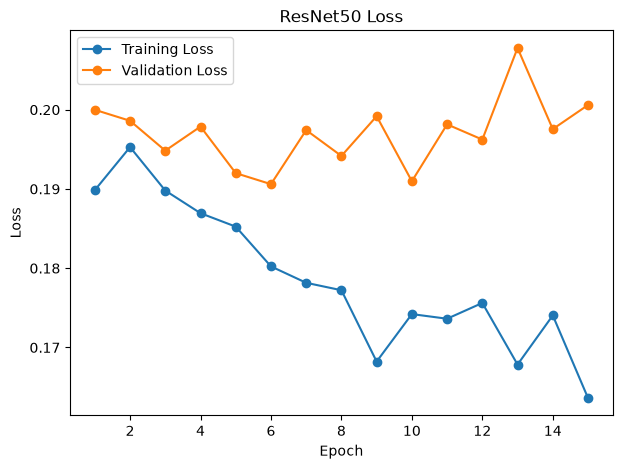

In [122]:
resnet_epochs = range(1, RESNET_EPOCHS + 1)

plt.figure(figsize=(7, 5))

plt.plot(
    resnet_epochs,
    resnet_train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    resnet_epochs,
    resnet_val_losses,
    marker="o",
    label="Validation Loss"
)

plt.title("ResNet50 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

##### The training loss steadily decreased during training, while the validation loss remained low and stable. The small gap between the two curves indicates good generalization and stable learning.

##### Plot ResNet50 accuracy

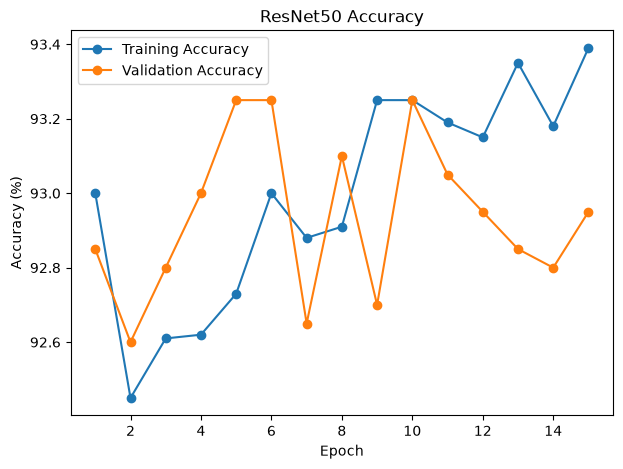

In [123]:
plt.figure(figsize=(7, 5))
plt.plot(
    resnet_epochs,
    resnet_train_accuracies,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    resnet_epochs,
    resnet_val_accuracies,
    marker="o",
    label="Validation Accuracy"
)

plt.title("ResNet50 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.show()

##### Both training and validation accuracy remained stable at approximately **93%** during training. The small difference between the curves indicates good generalization and no significant signs of overfitting.

##### Evaluation

In [124]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

resnet_model.eval()

true_labels = []
predicted_labels = []

with torch.no_grad():

    for images, labels in val_loader_small:

        images = images.to(device)

        outputs = resnet_model(images)

        predictions = outputs.argmax(dim=1)

        true_labels.extend(labels.numpy())
        predicted_labels.extend(predictions.cpu().numpy())

accuracy = accuracy_score(true_labels, predicted_labels)
precision = precision_score(true_labels, predicted_labels)
recall = recall_score(true_labels, predicted_labels)
f1 = f1_score(true_labels, predicted_labels)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9295
Precision: 0.9303733602421796
Recall   : 0.9275653923541247
F1 Score : 0.9289672544080605


##### Confusion Matrix

<Figure size 600x600 with 0 Axes>

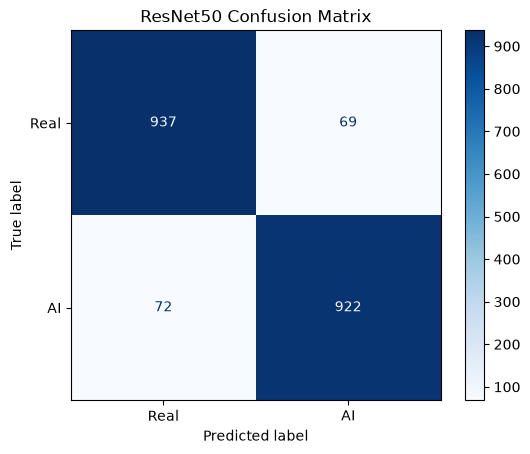

In [125]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    true_labels,
    predicted_labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Real","AI"]
)

plt.figure(figsize=(6,6))

disp.plot(cmap="Blues")

plt.title("ResNet50 Confusion Matrix")

plt.show()

##### ResNet50 correctly classified most images with only a small number of misclassifications. The balanced confusion matrix indicates that the model performed well on both real and AI-generated images, showing strong generalization performance.

In [154]:
# Save the trained ResNet50 model

import torch

torch.save(
    resnet_model.state_dict(),
    "resnet50_model.pth"
)

print("ResNet50 model saved successfully.")

ResNet50 model saved successfully.


### EfficientNet-B0 with Transfer Learning

##### Load EfficientNet-B0

In [126]:
efficientnet_model = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.DEFAULT
)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\fatem/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:01<00:00, 10.8MB/s]


##### Freeze pretrained layers

In [127]:
for parameter in efficientnet_model.parameters():
    parameter.requires_grad = False

##### Replace the classifier

In [128]:
number_of_features = efficientnet_model.classifier[1].in_features

# Replace the final layer with a new layer for two classes

efficientnet_model.classifier[1] = nn.Linear(
    number_of_features,
    2
)

In [129]:
efficientnet_model = efficientnet_model.to(device)

print(efficientnet_model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)


##### Loss Function and Optimizer

In [130]:
efficientnet_criterion = nn.CrossEntropyLoss()

# Update only the new classifier

efficientnet_optimizer = torch.optim.Adam(
    efficientnet_model.classifier.parameters(),
    lr=0.001
)

##### Test model output

In [131]:
images, labels = next(iter(train_loader_small))

images = images.to(device)

# Make predictions using EfficientNet-B0

outputs = efficientnet_model(images)

print("EfficientNet-B0 output shape:", outputs.shape)

EfficientNet-B0 output shape: torch.Size([64, 2])


##### Train EfficientNet-B0

In [132]:
EFFICIENTNET_EPOCHS = 15

# Save loss and accuracy values
efficientnet_train_losses = []
efficientnet_val_losses = []

efficientnet_train_accuracies = []
efficientnet_val_accuracies = []


for epoch in range(EFFICIENTNET_EPOCHS):

    # Training
    efficientnet_model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader_small:

        images = images.to(device)
        labels = labels.to(device)

        efficientnet_optimizer.zero_grad()

        outputs = efficientnet_model(images)
        loss = efficientnet_criterion(outputs, labels)

        loss.backward()
        efficientnet_optimizer.step()

        train_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        train_total += labels.size(0)
        train_correct += (predictions == labels).sum().item()


    train_loss = train_loss / len(train_loader_small)
    train_accuracy = 100 * train_correct / train_total


    # Validation
    efficientnet_model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader_small:

            images = images.to(device)
            labels = labels.to(device)

            outputs = efficientnet_model(images)
            loss = efficientnet_criterion(outputs, labels)

            val_loss += loss.item()

            predictions = outputs.argmax(dim=1)

            val_total += labels.size(0)
            val_correct += (predictions == labels).sum().item()


    val_loss = val_loss / len(val_loader_small)
    val_accuracy = 100 * val_correct / val_total


    # Save results
    efficientnet_train_losses.append(train_loss)
    efficientnet_val_losses.append(val_loss)

    efficientnet_train_accuracies.append(train_accuracy)
    efficientnet_val_accuracies.append(val_accuracy)


    # epoch results
    print(
        f"Epoch {epoch + 1}/{EFFICIENTNET_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.2f}%"
    )

Epoch 1/15 | Train Loss: 0.4155 | Train Accuracy: 82.26% | Val Loss: 0.3201 | Val Accuracy: 87.40%
Epoch 2/15 | Train Loss: 0.3314 | Train Accuracy: 86.02% | Val Loss: 0.2917 | Val Accuracy: 87.70%
Epoch 3/15 | Train Loss: 0.3138 | Train Accuracy: 86.68% | Val Loss: 0.2795 | Val Accuracy: 88.80%
Epoch 4/15 | Train Loss: 0.3037 | Train Accuracy: 87.20% | Val Loss: 0.2748 | Val Accuracy: 89.35%
Epoch 5/15 | Train Loss: 0.3019 | Train Accuracy: 87.21% | Val Loss: 0.2772 | Val Accuracy: 88.60%
Epoch 6/15 | Train Loss: 0.2924 | Train Accuracy: 87.48% | Val Loss: 0.2749 | Val Accuracy: 88.50%
Epoch 7/15 | Train Loss: 0.2964 | Train Accuracy: 87.44% | Val Loss: 0.2601 | Val Accuracy: 89.45%
Epoch 8/15 | Train Loss: 0.2910 | Train Accuracy: 87.72% | Val Loss: 0.2605 | Val Accuracy: 89.20%
Epoch 9/15 | Train Loss: 0.2970 | Train Accuracy: 87.16% | Val Loss: 0.2623 | Val Accuracy: 89.35%
Epoch 10/15 | Train Loss: 0.2897 | Train Accuracy: 87.83% | Val Loss: 0.2551 | Val Accuracy: 89.65%
Epoch 11/

##### Plot loss

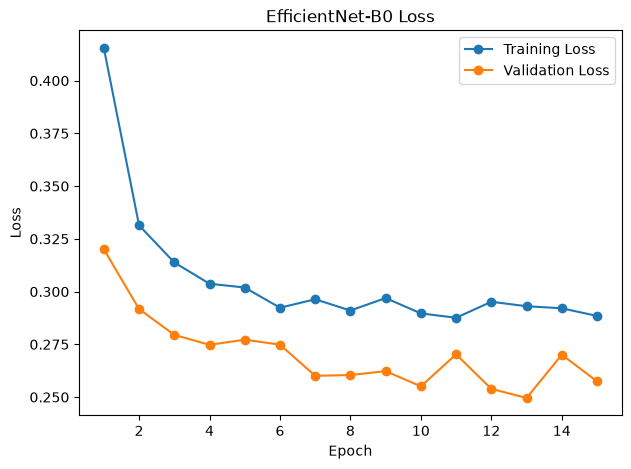

In [133]:
efficientnet_epochs = range(1, EFFICIENTNET_EPOCHS + 1)

# Plot training and validation loss

plt.figure(figsize=(7, 5))

plt.plot(
    efficientnet_epochs,
    efficientnet_train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    efficientnet_epochs,
    efficientnet_val_losses,
    marker="o",
    label="Validation Loss"
)

plt.title("EfficientNet-B0 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

##### The training and validation losses decreased during training and remained stable after the first few epochs. The smooth curves indicate stable learning and good generalization performance.

##### Plot accuracy

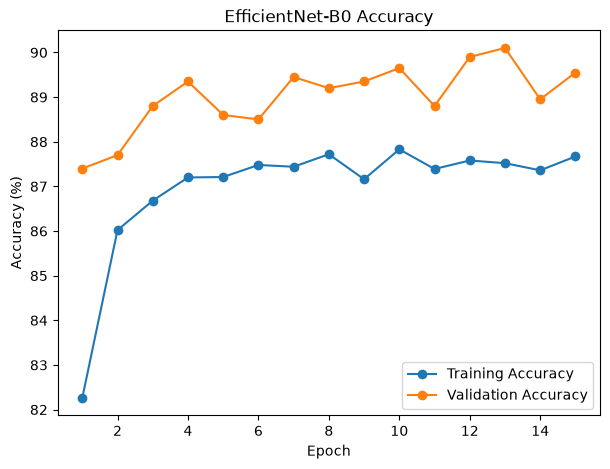

In [134]:
plt.figure(figsize=(7, 5))

plt.plot(
    efficientnet_epochs,
    efficientnet_train_accuracies,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    efficientnet_epochs,
    efficientnet_val_accuracies,
    marker="o",
    label="Validation Accuracy"
)

plt.title("EfficientNet-B0 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()

plt.show()

In [142]:
print(efficientnet_train_accuracies)
print(efficientnet_val_accuracies)

[82.26, 86.02, 86.68, 87.2, 87.21, 87.48, 87.44, 87.72, 87.16, 87.83, 87.39, 87.58, 87.52, 87.36, 87.67]
[87.4, 87.7, 88.8, 89.35, 88.6, 88.5, 89.45, 89.2, 89.35, 89.65, 88.8, 89.9, 90.1, 88.95, 89.55]


##### Both training and validation accuracy improved during training and remained stable throughout the experiment. The model achieved a maximum validation accuracy of approximately **90.1%**, indicating good classification performance and strong generalization.

In [139]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

efficientnet_model.eval()

true_labels = []
predicted_labels = []

with torch.no_grad():

    for images, labels in val_loader_small:

        images = images.to(device)

        outputs = efficientnet_model(images)

        predictions = outputs.argmax(dim=1)

        true_labels.extend(labels.numpy())
        predicted_labels.extend(predictions.cpu().numpy())

accuracy = accuracy_score(true_labels, predicted_labels)
precision = precision_score(true_labels, predicted_labels)
recall = recall_score(true_labels, predicted_labels)
f1 = f1_score(true_labels, predicted_labels)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.8955
Precision: 0.8699340245051838
Recall   : 0.9285714285714286
F1 Score : 0.8982968369829684


##### EfficientNet-B0 achieved an accuracy of **89.55%**, with a precision of **86.99%**, recall of **92.86%**, and an F1-score of **89.83%**.

##### The high recall shows that the model detected most AI-generated images, while the slightly lower precision indicates that some real images were incorrectly classified as AI-generated.

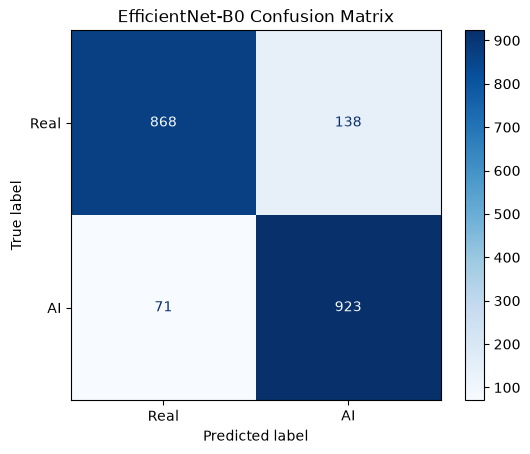

In [141]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create the confusion matrix
efficientnet_cm = confusion_matrix(
    true_labels,
    predicted_labels
)

# Display the confusion matrix
display = ConfusionMatrixDisplay(
    confusion_matrix=efficientnet_cm,
    display_labels=["Real", "AI"]
)

display.plot(cmap="Blues")

plt.title("EfficientNet-B0 Confusion Matrix")
plt.show()

##### EfficientNet-B0 Confusion Matrix Analysis

##### The confusion matrix shows that EfficientNet-B0 correctly classified **868 real images** and **923 AI-generated images**.

##### The model misclassified **138 real images as AI-generated** and **71 AI-generated images as real**.

##### Overall, EfficientNet-B0 achieved good classification performance with relatively few errors. Compared to the Custom CNN, it reduced the number of misclassifications and demonstrated better generalization, although ResNet50 achieved the best overall performance.

### Model Comparison

The three models are compared using accuracy, precision, recall, and F1-score.

All models were evaluated on the same validation set to ensure a fair comparison.

In [143]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Custom CNN",
        "ResNet50",
        "EfficientNet-B0"
    ],
    "Accuracy": [
        0.8580,
        0.9295,
        0.8955
    ],
    "Precision": [
        0.7973,
        0.9304,
        0.8699
    ],
    "Recall": [
        0.9577,
        0.9276,
        0.9286
    ],
    "F1 Score": [
        0.8702,
        0.9290,
        0.8983
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Custom CNN,0.8580,0.7973,0.9577,0.8702
1,ResNet50,0.9295,0.9304,0.9276,0.9290
2,EfficientNet-B0,0.8955,0.8699,0.9286,0.8983


In [144]:
results_percent = results.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

results_percent[metric_columns] = (
    results_percent[metric_columns] * 100
).round(2)

results_percent

,Model,Accuracy,Precision,Recall,F1 Score
0,Custom CNN,85.80,79.73,95.77,87.02
1,ResNet50,92.95,93.04,92.76,92.90
2,EfficientNet-B0,89.55,86.99,92.86,89.83


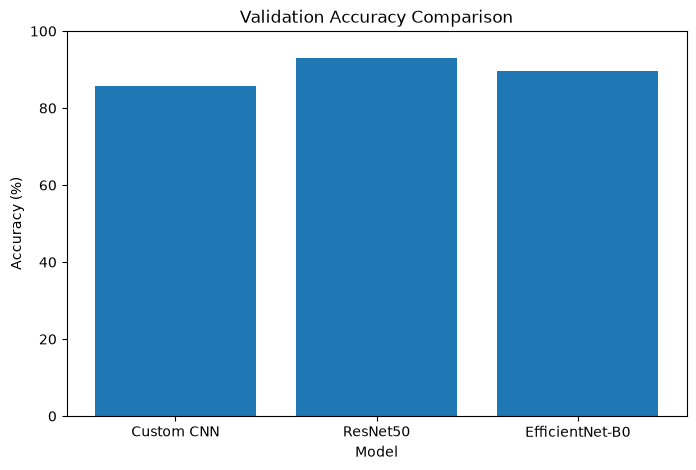

In [145]:
plt.figure(figsize=(8, 5))

plt.bar(
    results_percent["Model"],
    results_percent["Accuracy"]
)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

plt.show()

##### Validation Accuracy Comparison

The comparison shows that **ResNet50** achieved the highest validation accuracy (**92.95%**), followed by **EfficientNet-B0** (**89.55%**) and **Custom CNN** (**85.80%**).

The pretrained models outperformed the Custom CNN, demonstrating the advantage of transfer learning for distinguishing between real and AI-generated images.

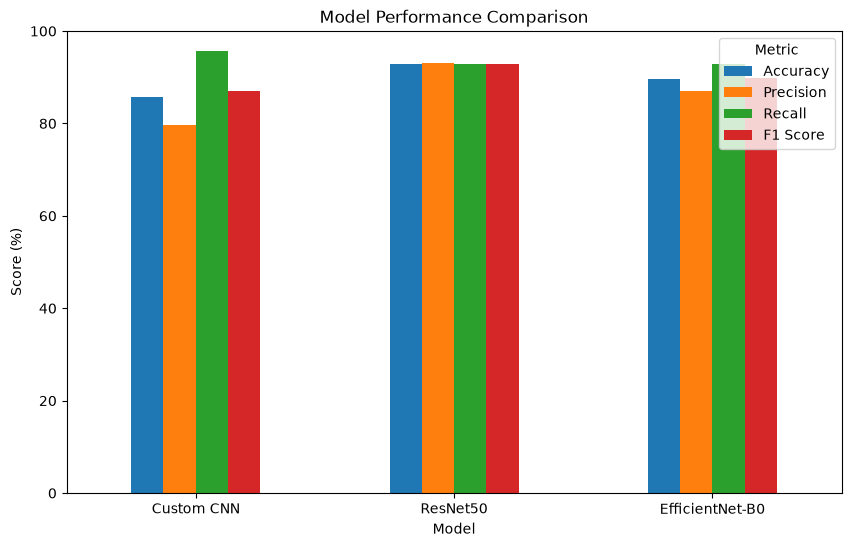

In [146]:
comparison_data = results_percent.set_index("Model")

comparison_data.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score (%)")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.legend(title="Metric")

plt.show()

##### The comparison shows that **ResNet50** achieved the highest validation accuracy (**92.95%**), followed by **EfficientNet-B0** (**89.55%**) and **Custom CNN** (**85.80%**).

##### The pretrained models outperformed the Custom CNN, demonstrating the advantage of transfer learning for distinguishing between real and AI-generated images.

### Answer to the Research Question

##### The experimental results show that CNN-based models can successfully distinguish between real photographs and AI-generated images.

Among the evaluated models, ResNet50 achieved the best performance with a validation accuracy of **92.95%**, followed by EfficientNet-B0 with **89.55%**, while the custom CNN achieved **85.80%**.

These results indicate that transfer learning significantly improves classification performance compared to a CNN trained from scratch. Although none of the models achieved perfect accuracy, all three models were able to classify most images correctly.

Therefore, the answer to the research question is **yes**: CNNs can effectively distinguish between real photographs and AI-generated images, especially when pretrained models are used.

### Conclusion


#### In this project, three different CNN-based approaches were compared for distinguishing between real photographs and AI-generated images: a custom CNN, ResNet50, and EfficientNet-B0.

#### The results showed that all three models were able to perform the classification task successfully. However, the pretrained models outperformed the custom CNN. Among them, ResNet50 achieved the best overall performance with the highest accuracy and F1-score, while EfficientNet-B0 also produced strong results. Although the custom CNN achieved a high recall, its overall accuracy was lower than the pretrained models.

#### Overall, the comparison demonstrates that transfer learning provides a significant advantage over training a CNN from scratch for this image classification task.

##### *MML*: Claude and Google were used to help understand the assignment requirements and for code debugging.